Libraries imported successfully!

PART A - PRACTICE QUESTIONS

Dataset Shape:
(500, 4)

Target Shape:
(500,)

Data standardized successfully!

SVM model trained successfully!

Cross Validation Scores:
[1. 1. 1. 1. 1.]

Mean Cross Validation Accuracy:
1.0

Best Parameters:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross Validation Score:
1.0

Best SVM model trained successfully!

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       250
           1       1.00      1.00      1.00       250

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500


SVM model saved using Joblib!
SVM model saved using Pickle!
Scaler saved successfully!

Model loaded successfully!

New Data Predictions:
[0 0]

PART B - MAJOR PROJECT
CUSTOMER SEGMENTATION

First 10 Customers:
   CustomerID  Age  Annual Inco

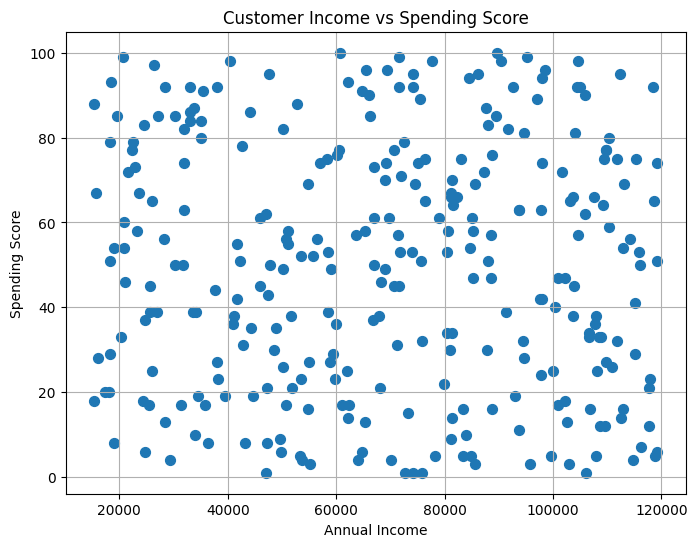


Customer data scaled successfully!


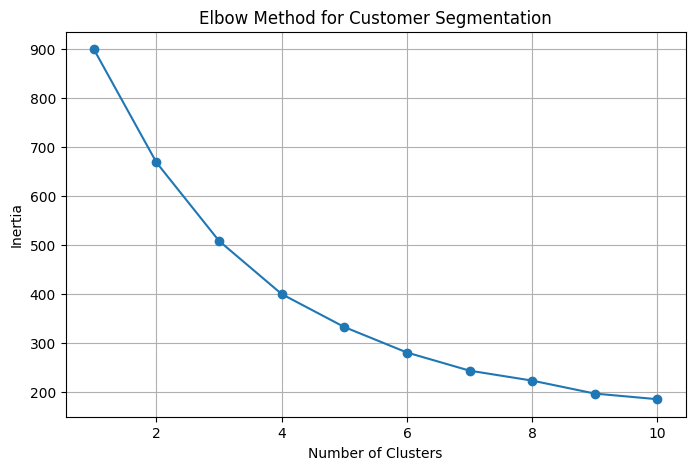


Cluster Labels:
[0 2 1 0 0 1 2 2 2 0 0 2 2 2 0 1 0 1 2 0]

Customer Dataset with Clusters:
   CustomerID  Age  Annual Income  Spending Score  Cluster
0           1   56         112888              16        0
1           2   46          54790              69        2
2           3   32          20600              99        1
3           4   60         109660              12        0
4           5   25         108179              25        0
5           6   38          55764              52        1
6           7   56          89543              85        2
7           8   36          60714             100        2
8           9   40          71835              53        2
9          10   28         117946              23        0

Number of Customers in Each Cluster:
Cluster
0     99
1    103
2     98
Name: count, dtype: int64

Cluster Centers:
         Age  Annual Income  Spending Score
0  43.626263   78985.797980       19.393939
1  25.805825   59263.223301       53.980583
2  48.4183

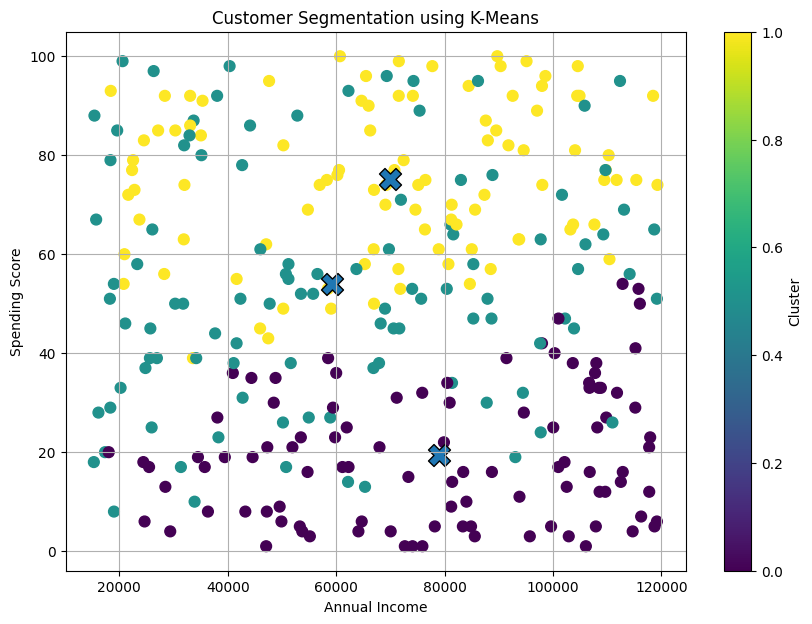

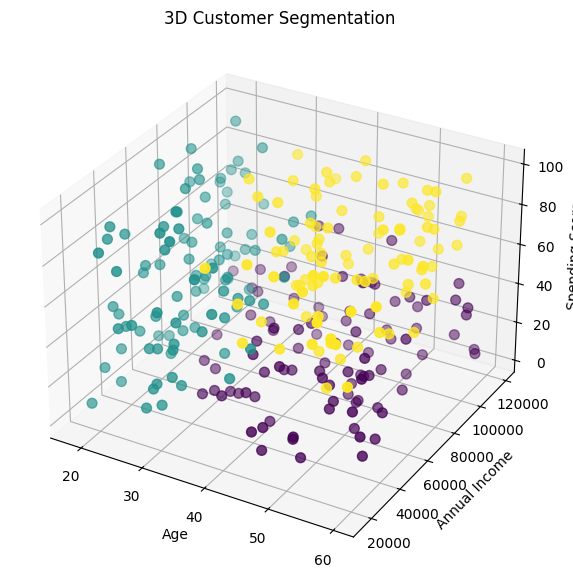


Cluster Characteristics:
               Age  Annual Income  Spending Score
Cluster                                          
0        43.626263   78985.797980       19.393939
1        25.805825   59263.223301       53.980583
2        48.418367   69928.040816       75.193878

Customer Groups:
    CustomerID  Age  Annual Income  Spending Score  Cluster   Customer Group
0            1   56         112888              16        0     Low Spenders
1            2   46          54790              69        2    High Spenders
2            3   32          20600              99        1  Medium Spenders
3            4   60         109660              12        0     Low Spenders
4            5   25         108179              25        0     Low Spenders
5            6   38          55764              52        1  Medium Spenders
6            7   56          89543              85        2    High Spenders
7            8   36          60714             100        2    High Spenders
8            

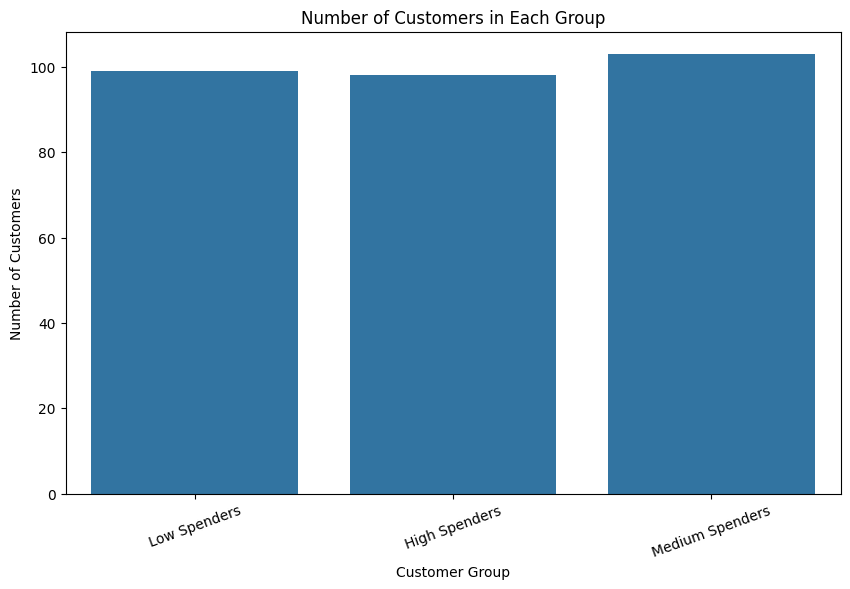

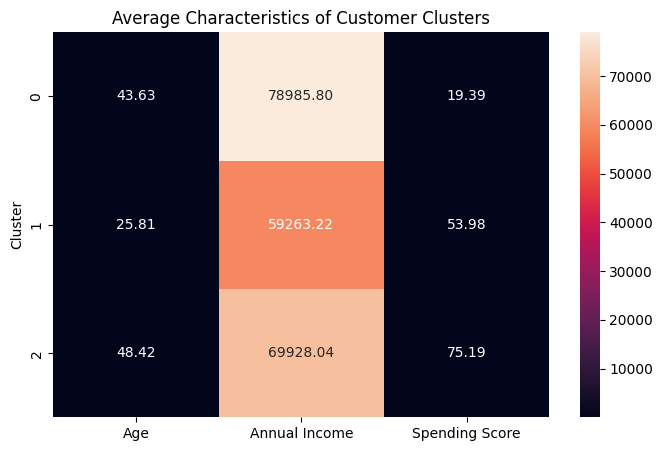


K-Means Inertia:
508.61664643423734

customer_segments.csv saved successfully!
Customer K-Means model saved!
Customer scaler saved!
Customer K-Means model saved using Pickle!

Customer model loaded successfully!

New Customer Predictions:
   Age  Annual Income  Spending Score  Cluster   Customer Group
0   25          30000              85        1  Medium Spenders
1   50         100000              20        0     Low Spenders
2   35          60000              55        1  Medium Spenders

WEEK 4 PROJECT COMPLETED

Practice Questions Completed:
1. Cross-validation using cross_val_score
2. GridSearchCV for SVM
3. Model saving using Joblib
4. Model loading and prediction

Major Project Completed:
Customer Segmentation using K-Means

Number of Clusters:
3

Files Created:
1. svm_model.joblib
2. svm_model.pkl
3. scaler.joblib
4. customer_segments.csv
5. customer_kmeans.joblib
6. customer_kmeans.pkl
7. customer_scaler.joblib

All Week 4 tasks completed successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# ============================================================
# WEEK 4 - MODEL EVALUATION & OPTIMIZATION
# MAJOR PROJECT: CUSTOMER SEGMENTATION USING K-MEANS
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from sklearn.datasets import make_blobs
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    adjusted_rand_score
)

print("Libraries imported successfully!")


# ============================================================
# PART A - PRACTICE QUESTIONS
# ============================================================

print("\n========================================")
print("PART A - PRACTICE QUESTIONS")
print("========================================")


# -----------------------------
# 2. CREATE SAMPLE CLASSIFICATION DATA
# -----------------------------

X, y = make_blobs(
    n_samples=500,
    centers=2,
    n_features=4,
    random_state=42,
    cluster_std=2.0
)

print("\nDataset Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


# -----------------------------
# 3. STANDARDIZE DATA
# -----------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData standardized successfully!")


# -----------------------------
# 4. CREATE SVM MODEL
# -----------------------------

svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_model.fit(X_scaled, y)

print("\nSVM model trained successfully!")


# -----------------------------
# 5. CROSS VALIDATION
# -----------------------------

cv_scores = cross_val_score(
    svm_model,
    X_scaled,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCross Validation Scores:")
print(cv_scores)

print("\nMean Cross Validation Accuracy:")
print(cv_scores.mean())


# -----------------------------
# 6. GRIDSEARCHCV FOR SVM
# -----------------------------

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_scaled, y)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)


# -----------------------------
# 7. BEST SVM MODEL
# -----------------------------

best_svm = grid_search.best_estimator_

best_svm.fit(X_scaled, y)

predictions = best_svm.predict(X_scaled)

print("\nBest SVM model trained successfully!")


# -----------------------------
# 8. MODEL ACCURACY
# -----------------------------

accuracy = accuracy_score(
    y,
    predictions
)

print("\nAccuracy:")
print(accuracy)


# -----------------------------
# 9. CLASSIFICATION REPORT
# -----------------------------

print("\nClassification Report:")
print(
    classification_report(
        y,
        predictions
    )
)


# -----------------------------
# 10. SAVE MODEL USING JOBLIB
# -----------------------------

joblib.dump(
    best_svm,
    "svm_model.joblib"
)

print("\nSVM model saved using Joblib!")


# -----------------------------
# 11. SAVE MODEL USING PICKLE
# -----------------------------

with open(
    "svm_model.pkl",
    "wb"
) as file:

    pickle.dump(
        best_svm,
        file
    )

print("SVM model saved using Pickle!")


# -----------------------------
# 12. SAVE SCALER
# -----------------------------

joblib.dump(
    scaler,
    "scaler.joblib"
)

print("Scaler saved successfully!")


# -----------------------------
# 13. LOAD MODEL
# -----------------------------

loaded_model = joblib.load(
    "svm_model.joblib"
)

loaded_scaler = joblib.load(
    "scaler.joblib"
)

print("\nModel loaded successfully!")


# -----------------------------
# 14. PREDICT ON NEW DATA
# -----------------------------

new_data = np.array([
    [2.0, 3.0, 2.5, 3.0],
    [-2.0, -3.0, -2.5, -3.0]
])

new_data_scaled = loaded_scaler.transform(
    new_data
)

new_predictions = loaded_model.predict(
    new_data_scaled
)

print("\nNew Data Predictions:")
print(new_predictions)


# ============================================================
# PART B - MAJOR PROJECT
# CUSTOMER SEGMENTATION USING K-MEANS
# ============================================================

print("\n========================================")
print("PART B - MAJOR PROJECT")
print("CUSTOMER SEGMENTATION")
print("========================================")


# -----------------------------
# 15. CREATE CUSTOMER DATASET
# -----------------------------
# Features:
# Age
# Annual Income
# Spending Score

np.random.seed(42)

n_customers = 300

age = np.random.randint(
    18,
    61,
    n_customers
)

income = np.random.randint(
    15000,
    120001,
    n_customers
)

spending_score = np.random.randint(
    1,
    101,
    n_customers
)

customer_df = pd.DataFrame({
    "CustomerID": range(1, n_customers + 1),
    "Age": age,
    "Annual Income": income,
    "Spending Score": spending_score
})

print("\nFirst 10 Customers:")
print(customer_df.head(10))


# -----------------------------
# 16. DATASET INFORMATION
# -----------------------------

print("\nDataset Shape:")
print(customer_df.shape)

print("\nDataset Information:")
print(customer_df.info())

print("\nMissing Values:")
print(customer_df.isnull().sum())


# -----------------------------
# 17. STATISTICAL SUMMARY
# -----------------------------

print("\nStatistical Summary:")
print(
    customer_df.describe()
)


# -----------------------------
# 18. CHECK DUPLICATES
# -----------------------------

print("\nNumber of Duplicate Rows:")
print(
    customer_df.duplicated().sum()
)


# -----------------------------
# 19. VISUALIZE CUSTOMER DATA
# -----------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    customer_df["Annual Income"],
    customer_df["Spending Score"],
    s=50
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title(
    "Customer Income vs Spending Score"
)

plt.grid(True)

plt.show()


# -----------------------------
# 20. SELECT FEATURES
# -----------------------------

customer_features = customer_df[
    [
        "Age",
        "Annual Income",
        "Spending Score"
    ]
]


# -----------------------------
# 21. SCALE CUSTOMER DATA
# -----------------------------

customer_scaler = StandardScaler()

customer_scaled = customer_scaler.fit_transform(
    customer_features
)

print("\nCustomer data scaled successfully!")


# -----------------------------
# 22. ELBOW METHOD
# -----------------------------

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(customer_scaled)

    inertia.append(
        kmeans.inertia_
    )


# Plot Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method for Customer Segmentation"
)

plt.grid(True)

plt.show()


# -----------------------------
# 23. APPLY K-MEANS
# -----------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_clusters = kmeans.fit_predict(
    customer_scaled
)

print("\nCluster Labels:")
print(
    customer_clusters[:20]
)


# -----------------------------
# 24. ADD CLUSTERS TO DATASET
# -----------------------------

customer_df["Cluster"] = customer_clusters

print("\nCustomer Dataset with Clusters:")
print(
    customer_df.head(10)
)


# -----------------------------
# 25. CLUSTER COUNTS
# -----------------------------

print("\nNumber of Customers in Each Cluster:")

print(
    customer_df["Cluster"].value_counts().sort_index()
)


# -----------------------------
# 26. CLUSTER CENTERS
# -----------------------------

cluster_centers = customer_scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    cluster_centers,
    columns=[
        "Age",
        "Annual Income",
        "Spending Score"
    ]
)

print("\nCluster Centers:")
print(
    centers_df
)


# -----------------------------
# 27. VISUALIZE CUSTOMER CLUSTERS
# -----------------------------

plt.figure(figsize=(10, 7))

plt.scatter(
    customer_df["Annual Income"],
    customer_df["Spending Score"],
    c=customer_df["Cluster"],
    cmap="viridis",
    s=60
)

plt.scatter(
    cluster_centers[:, 1],
    cluster_centers[:, 2],
    marker="X",
    s=250,
    edgecolors="black"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title(
    "Customer Segmentation using K-Means"
)

plt.colorbar(
    label="Cluster"
)

plt.grid(True)

plt.show()


# -----------------------------
# 28. 3D CUSTOMER VISUALIZATION
# -----------------------------

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    customer_df["Age"],
    customer_df["Annual Income"],
    customer_df["Spending Score"],
    c=customer_df["Cluster"],
    cmap="viridis",
    s=50
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Spending Score")

ax.set_title(
    "3D Customer Segmentation"
)

plt.show()


# -----------------------------
# 29. FIND CLUSTER CHARACTERISTICS
# -----------------------------

cluster_summary = customer_df.groupby(
    "Cluster"
)[
    [
        "Age",
        "Annual Income",
        "Spending Score"
    ]
].mean()

print("\nCluster Characteristics:")
print(
    cluster_summary
)


# -----------------------------
# 30. ASSIGN CUSTOMER GROUP NAMES
# -----------------------------

# Identify clusters based on spending score

spending_means = customer_df.groupby(
    "Cluster"
)["Spending Score"].mean()

sorted_clusters = (
    spending_means
    .sort_values()
    .index
    .tolist()
)

cluster_names = {}

cluster_names[
    sorted_clusters[0]
] = "Low Spenders"

cluster_names[
    sorted_clusters[1]
] = "Medium Spenders"

cluster_names[
    sorted_clusters[2]
] = "High Spenders"


customer_df["Customer Group"] = (
    customer_df["Cluster"]
    .map(cluster_names)
)


# -----------------------------
# 31. DISPLAY CUSTOMER GROUPS
# -----------------------------

print("\nCustomer Groups:")

print(
    customer_df[
        [
            "CustomerID",
            "Age",
            "Annual Income",
            "Spending Score",
            "Cluster",
            "Customer Group"
        ]
    ].head(20)
)


# -----------------------------
# 32. GROUP COUNTS
# -----------------------------

print("\nCustomer Group Counts:")

print(
    customer_df["Customer Group"]
    .value_counts()
)


# -----------------------------
# 33. GROUP VISUALIZATION
# -----------------------------

plt.figure(figsize=(10, 6))

sns.countplot(
    data=customer_df,
    x="Customer Group"
)

plt.xlabel("Customer Group")
plt.ylabel("Number of Customers")

plt.title(
    "Number of Customers in Each Group"
)

plt.xticks(rotation=20)

plt.show()


# -----------------------------
# 34. HEATMAP OF CLUSTER MEANS
# -----------------------------

plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_summary,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Average Characteristics of Customer Clusters"
)

plt.show()


# -----------------------------
# 35. MODEL INERTIA
# -----------------------------

print("\nK-Means Inertia:")
print(
    kmeans.inertia_
)


# -----------------------------
# 36. SAVE CUSTOMER DATASET
# -----------------------------

customer_df.to_csv(
    "customer_segments.csv",
    index=False
)

print(
    "\ncustomer_segments.csv saved successfully!"
)


# -----------------------------
# 37. SAVE K-MEANS MODEL
# -----------------------------

joblib.dump(
    kmeans,
    "customer_kmeans.joblib"
)

print(
    "Customer K-Means model saved!"
)


# -----------------------------
# 38. SAVE CUSTOMER SCALER
# -----------------------------

joblib.dump(
    customer_scaler,
    "customer_scaler.joblib"
)

print(
    "Customer scaler saved!"
)


# -----------------------------
# 39. SAVE MODEL USING PICKLE
# -----------------------------

with open(
    "customer_kmeans.pkl",
    "wb"
) as file:

    pickle.dump(
        kmeans,
        file
    )

print(
    "Customer K-Means model saved using Pickle!"
)


# -----------------------------
# 40. LOAD CUSTOMER MODEL
# -----------------------------

loaded_customer_model = joblib.load(
    "customer_kmeans.joblib"
)

loaded_customer_scaler = joblib.load(
    "customer_scaler.joblib"
)

print(
    "\nCustomer model loaded successfully!"
)


# -----------------------------
# 41. PREDICT NEW CUSTOMER
# -----------------------------

new_customer = np.array([
    [25, 30000, 85],
    [50, 100000, 20],
    [35, 60000, 55]
])

new_customer_scaled = (
    loaded_customer_scaler
    .transform(new_customer)
)

new_customer_clusters = (
    loaded_customer_model
    .predict(new_customer_scaled)
)


# -----------------------------
# 42. DISPLAY NEW CUSTOMER PREDICTIONS
# -----------------------------

new_customer_result = pd.DataFrame(
    new_customer,
    columns=[
        "Age",
        "Annual Income",
        "Spending Score"
    ]
)

new_customer_result[
    "Cluster"
] = new_customer_clusters

new_customer_result[
    "Customer Group"
] = new_customer_result[
    "Cluster"
].map(cluster_names)

print(
    "\nNew Customer Predictions:"
)

print(
    new_customer_result
)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n========================================")
print("WEEK 4 PROJECT COMPLETED")
print("========================================")

print("\nPractice Questions Completed:")
print("1. Cross-validation using cross_val_score")
print("2. GridSearchCV for SVM")
print("3. Model saving using Joblib")
print("4. Model loading and prediction")

print("\nMajor Project Completed:")
print("Customer Segmentation using K-Means")

print("\nNumber of Clusters:")
print("3")

print("\nFiles Created:")
print("1. svm_model.joblib")
print("2. svm_model.pkl")
print("3. scaler.joblib")
print("4. customer_segments.csv")
print("5. customer_kmeans.joblib")
print("6. customer_kmeans.pkl")
print("7. customer_scaler.joblib")

print("\nAll Week 4 tasks completed successfully!")